=== 1. DATA LOADING AND NLP CURATION ===
Data curated successfully. Processed 714 herbs.

=== 2. FIGURE 1: TRIPARTITE KNOWLEDGE GRAPH ===


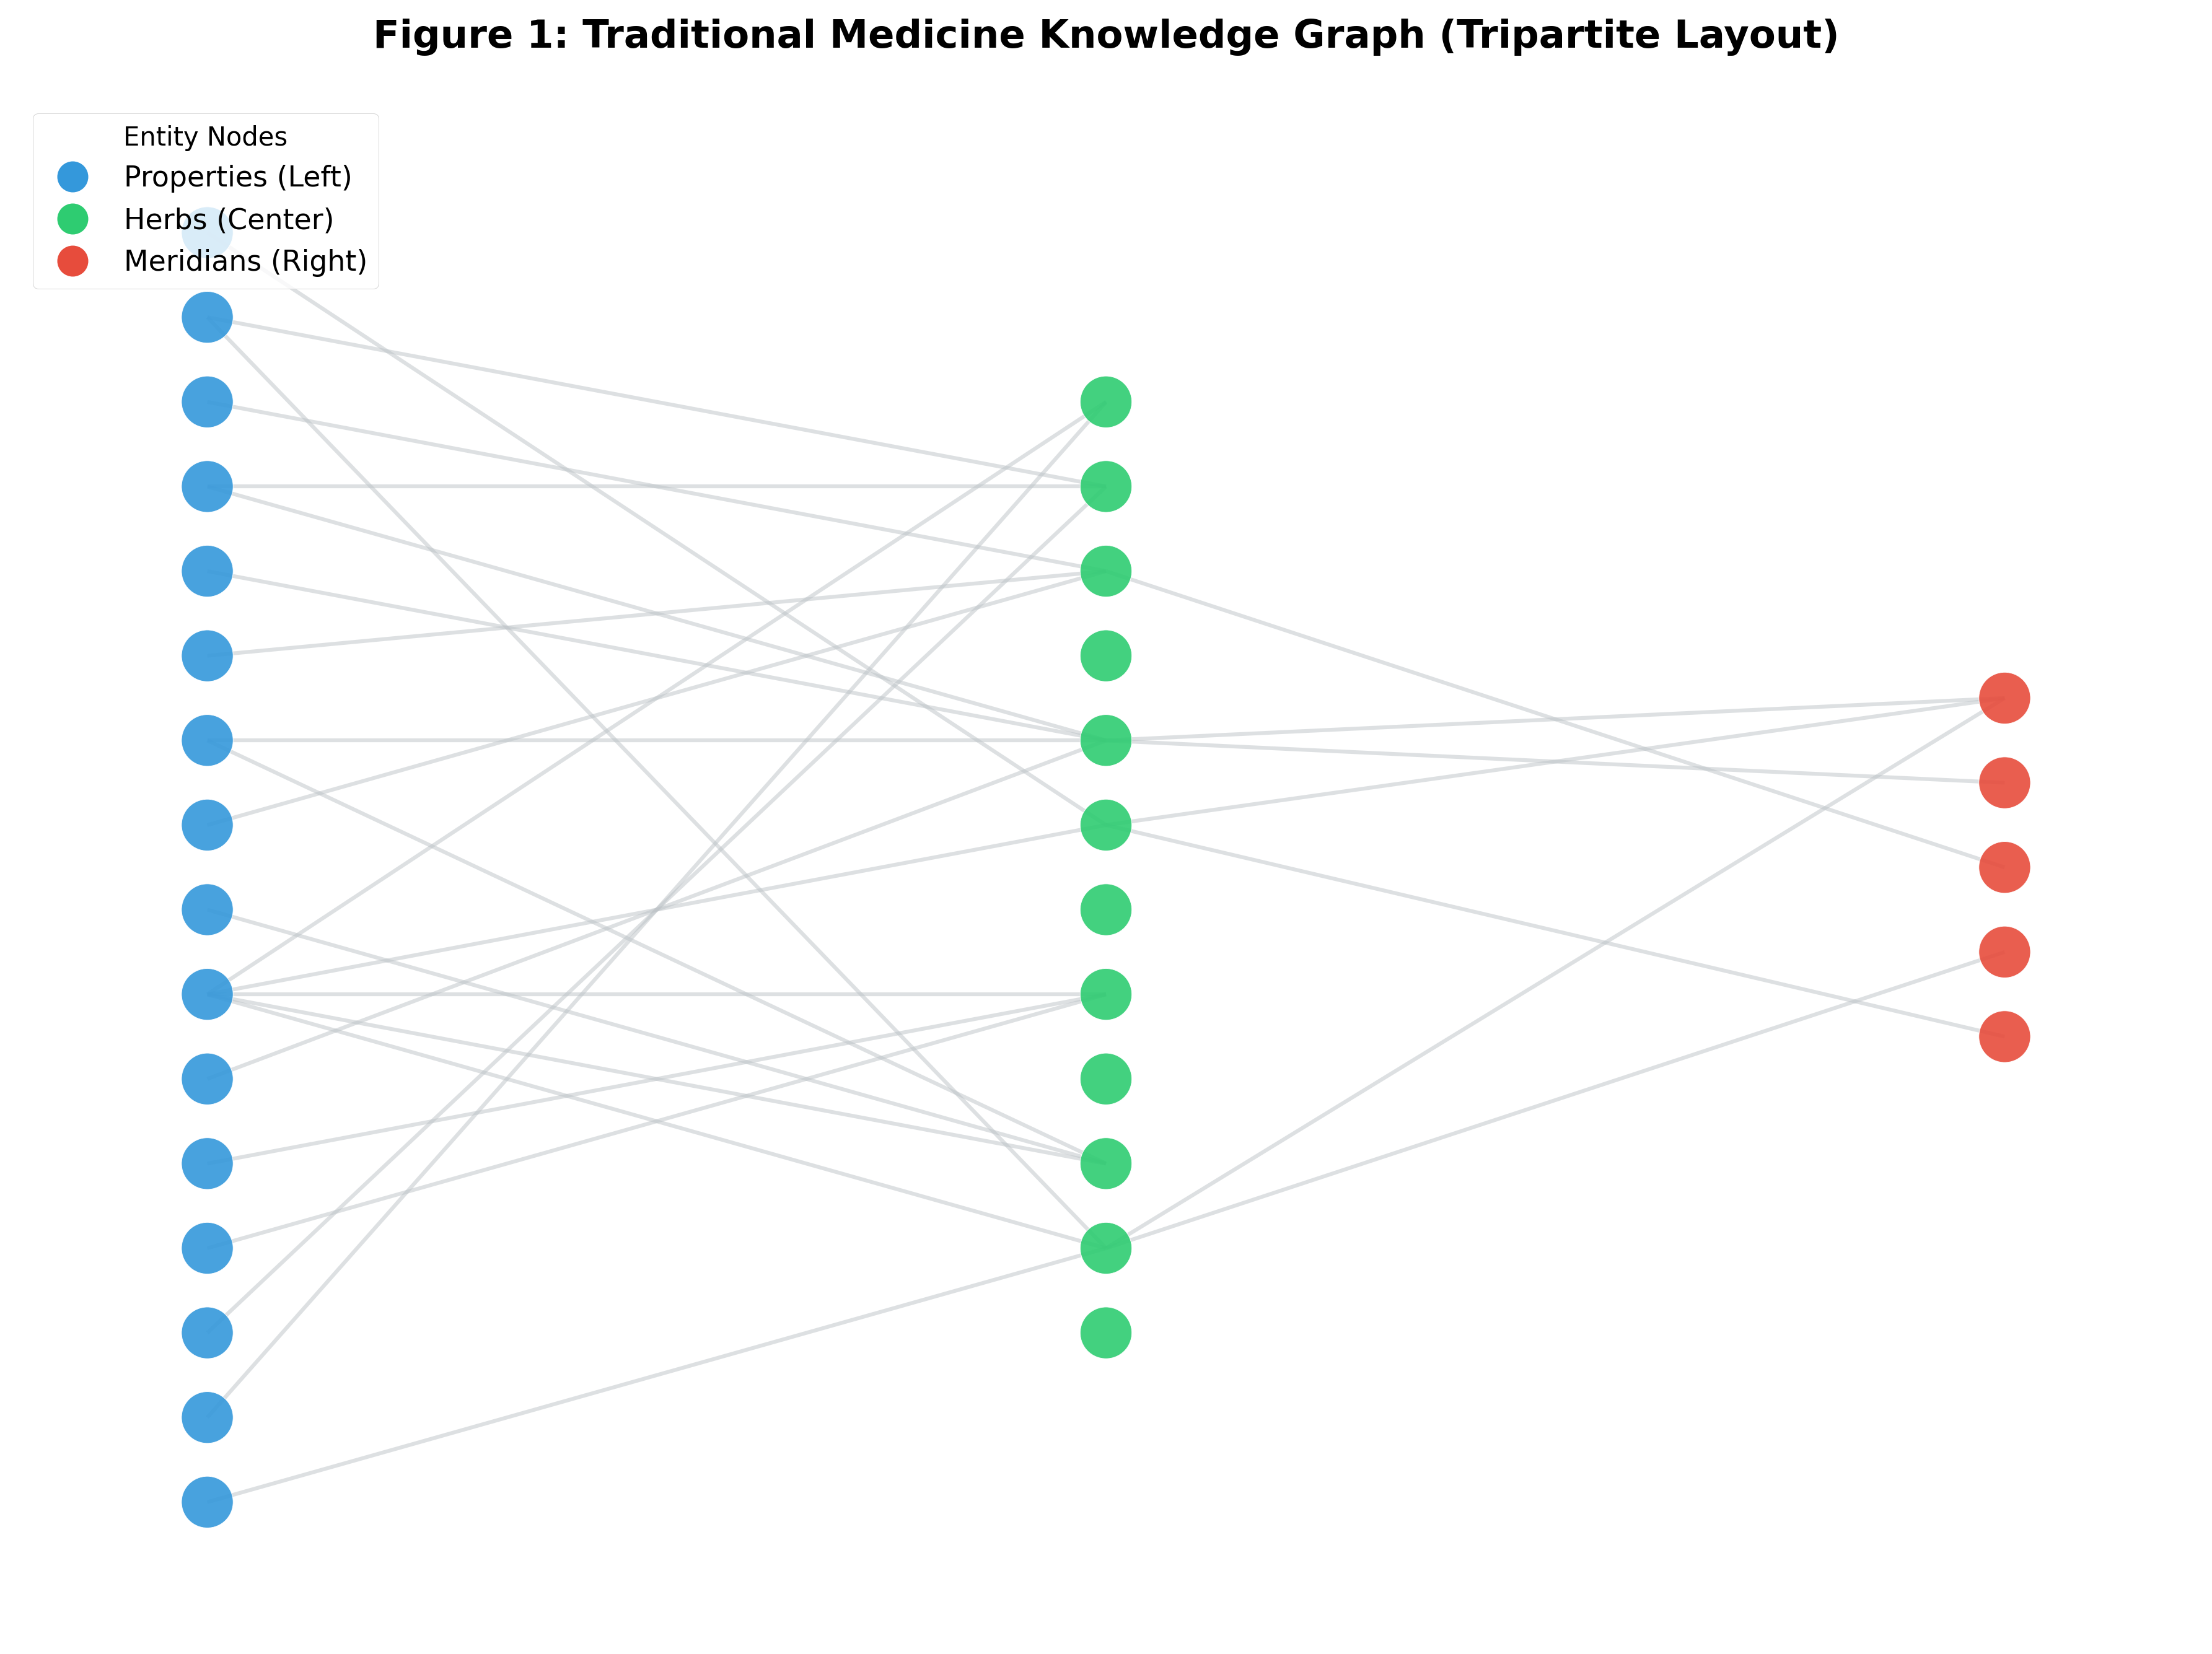


=== 3. FIGURE 2: HERB-HERB SIMILARITY BACKBONE ===


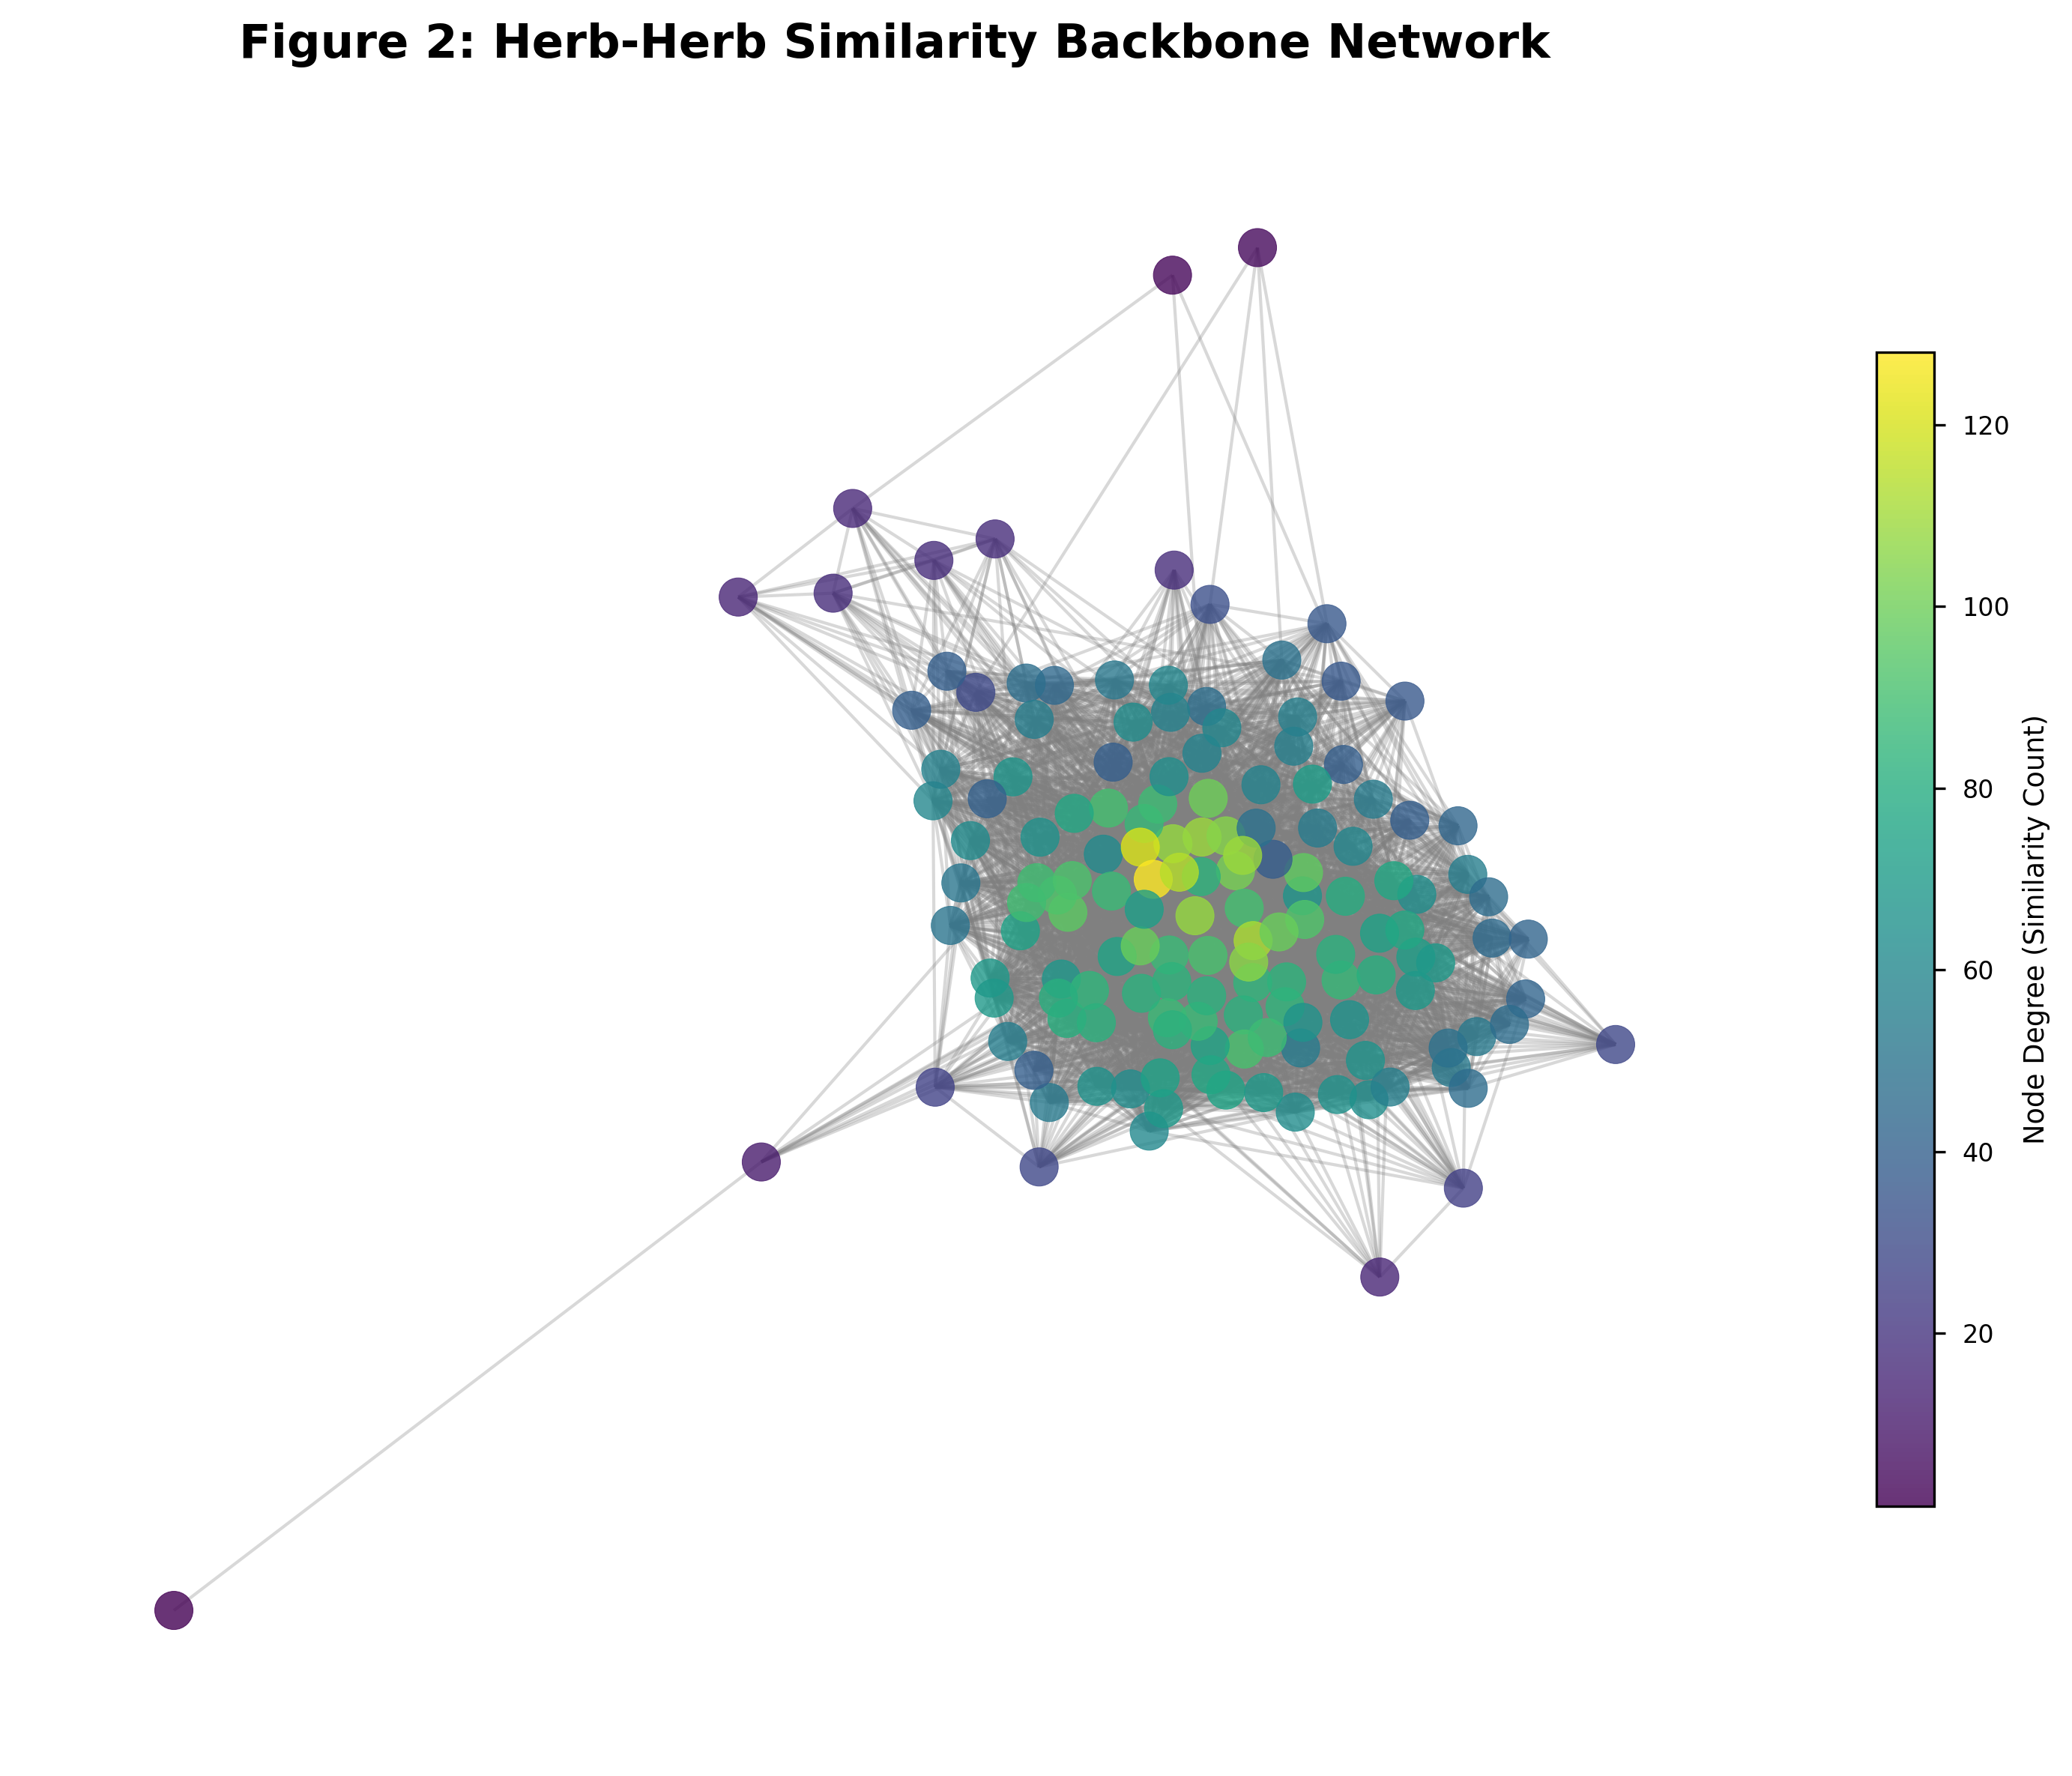


=== PHASE 1 COMPLETE ===
Exported 'curated_tm_features.pkl' for Topo-Analysis.


In [5]:
# =====================================================================
# 01_Data_Curation_KG.ipynb
# Phase 1: NLP Processing, Tripartite Graph, and Similarity Backbone
# =====================================================================
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-paper')

print("=== 1. DATA LOADING AND NLP CURATION ===")
try:
    df = pd.read_csv('ViThuoc_final.csv')
except FileNotFoundError:
    print("ERROR: Please upload 'ViThuoc_final.csv' to the Colab environment.")
    exit()

# Dynamically identify columns to avoid KeyError
cols = [c.lower().strip() for c in df.columns]
ten_col = next((c for c, lc in zip(df.columns, cols) if 'tên' in lc or 'ten' in lc), df.columns[1])
# Fix: Change search terms for 'tinh_vi_col' to remove diacritics to match actual column names
tinh_vi_col = next((c for c, lc in zip(df.columns, cols) if 'tinh' in lc and 'vi' in lc), None)
quy_kinh_col = next((c for c, lc in zip(df.columns, cols) if 'quy' in lc and 'kinh' in lc), None)

def clean_text(text):
    if pd.isna(text) or '(Không ghi rõ)' in str(text) or '(Không có)' in str(text):
        return []
    text = str(text).replace('.', '').strip()
    return [x.strip().capitalize() for x in re.split(r'[,;+]', text) if x.strip()]

# Parse properties for graph and future TDA
df['Parsed_TinhVi'] = df[tinh_vi_col].apply(clean_text)
df['Parsed_QuyKinh'] = df[quy_kinh_col].apply(clean_text)
# Combine for the binary feature matrix later
df['All_Properties'] = df['Parsed_TinhVi'] + df['Parsed_QuyKinh']

# Build the Tripartite Graph
G_tripartite = nx.Graph()
herb_dict = {}

for index, row in df.iterrows():
    herb = str(row[ten_col]).strip()
    G_tripartite.add_node(herb, type='Herb')
    properties = set()

    for qk in row['Parsed_QuyKinh']:
        node_name = f"Meridian: {qk}"
        G_tripartite.add_node(node_name, type='Meridian')
        G_tripartite.add_edge(herb, node_name)
        properties.add(node_name)

    for tv in row['Parsed_TinhVi']:
        node_name = f"Property: {tv}"
        G_tripartite.add_node(node_name, type='Property')
        G_tripartite.add_edge(herb, node_name)
        properties.add(node_name)

    herb_dict[herb] = properties

print(f"Data curated successfully. Processed {len(herb_dict)} herbs.")

# =====================================================================
print("\n=== 2. FIGURE 1: TRIPARTITE KNOWLEDGE GRAPH ===")
# Extract a small ego-graph for visualization clarity
core_herbs = list(herb_dict.keys())[:12]
ego_G = nx.Graph()

for h in core_herbs:
    ego_G.add_node(h, type='Herb', layer=1)
    for n in G_tripartite.neighbors(h):
        if G_tripartite.nodes[n]['type'] == 'Property':
            ego_G.add_node(n, type='Property', layer=0)
        elif G_tripartite.nodes[n]['type'] == 'Meridian':
            ego_G.add_node(n, type='Meridian', layer=2)
        ego_G.add_edge(h, n)

plt.figure(figsize=(12, 9), dpi=300)
pos = nx.multipartite_layout(ego_G, subset_key="layer", align="vertical")

node_colors = ['#2ecc71' if ego_G.nodes[n].get('type') == 'Herb'
               else '#e74c3c' if ego_G.nodes[n].get('type') == 'Meridian'
               else '#3498db' for n in ego_G.nodes()]

nx.draw_networkx_edges(ego_G, pos, edge_color='#bdc3c7', alpha=0.5, width=1.5)
nx.draw_networkx_nodes(ego_G, pos, node_color=node_colors, node_size=400, alpha=0.9, edgecolors='white')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Properties (Left)', markerfacecolor='#3498db', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Herbs (Center)', markerfacecolor='#2ecc71', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Meridians (Right)', markerfacecolor='#e74c3c', markersize=12)
]
plt.legend(handles=legend_elements, loc='upper left', title="Entity Nodes", fontsize=11)
plt.title("Figure 1: Traditional Medicine Knowledge Graph (Tripartite Layout)", fontsize=15, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("Fig1_Core_Knowledge_Graph_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
print("\n=== 3. FIGURE 2: HERB-HERB SIMILARITY BACKBONE ===")
G_backbone = nx.Graph()
herbs_list = list(herb_dict.keys())

for i in range(len(herbs_list)):
    G_backbone.add_node(herbs_list[i])
    for j in range(i + 1, len(herbs_list)):
        shared_props = herb_dict[herbs_list[i]].intersection(herb_dict[herbs_list[j]])
        if len(shared_props) >= 2: # Threshold Tau >= 2
            G_backbone.add_edge(herbs_list[i], herbs_list[j])

# Extract Largest Connected Component
largest_cc = max(nx.connected_components(G_backbone), key=len)
G_backbone_core = G_backbone.subgraph(largest_cc).copy()

# Plot a subgraph for visualization
sub_nodes = list(G_backbone_core.nodes())[:150]
G_vis = G_backbone_core.subgraph(sub_nodes)

plt.figure(figsize=(10, 8), dpi=300)
pos_herb = nx.spring_layout(G_vis, k=0.15, seed=42)
degrees = [G_vis.degree(n) for n in G_vis.nodes()]

nodes = nx.draw_networkx_nodes(G_vis, pos_herb, node_size=150, cmap=plt.cm.viridis, node_color=degrees, alpha=0.8)
nx.draw_networkx_edges(G_vis, pos_herb, alpha=0.3, edge_color='gray')

plt.colorbar(nodes, label="Node Degree (Similarity Count)", shrink=0.7)
plt.title("Figure 2: Herb-Herb Similarity Backbone Network", fontsize=15, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig("Fig2_Herb_Similarity_Network_EN.png", bbox_inches='tight')
plt.show()

# =====================================================================
# Export curated data for TDA notebook
df_cleaned = df[[ten_col, 'All_Properties']].copy()
df_cleaned.to_pickle('curated_tm_features.pkl')
print("\n=== PHASE 1 COMPLETE ===")
print("Exported 'curated_tm_features.pkl' for Topo-Analysis.")